<a href="https://colab.research.google.com/github/Abrar-404/AI-ML_Practices_and_Assignments/blob/main/Module_22_Practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Student Practice: DBSCAN for Spatial Customer Density & Anomaly Detection

### Scenario
You are working for an e-commerce giant. To optimize delivery routes and detect fraudulent behavior, you need to analyze spatial customer data. Unlike standard demographic data, spatial patterns are often non-spherical and contain significant noise (outliers).

In this session, we will focus on:
1. Identifying dense regions of customers.
2. Spotting anomalies (potential fraud or isolated users) that don't fit into any cluster.

## Theory Recap: Why DBSCAN?

**DBSCAN** (Density-Based Spatial Clustering of Applications with Noise) differs from K-Means because it doesn't assume clusters are circular.

**Key Concepts:**
*   **Epsilon (ε):** The maximum distance between two samples for one to be considered as in the neighborhood of the other.
*   **MinPts:** The number of samples in a neighborhood for a point to be considered as a core point.
*   **Core Points:** Dense interior points.
*   **Border Points:** On the edge of a cluster, reachable from a core point but not dense themselves.
*   **Noise (Anomalies):** Points not reachable from any core point.

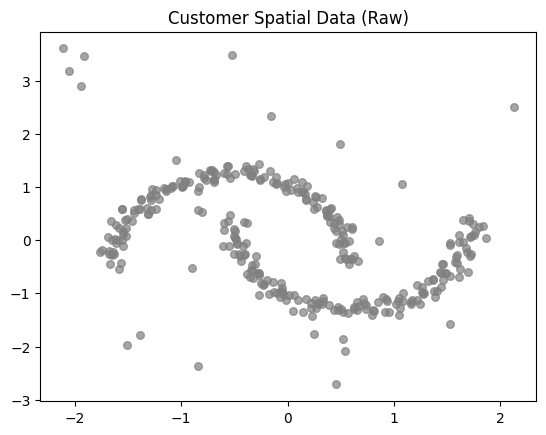

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.cluster import KMeans, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
import seaborn as sns

# 1. Generate synthetic non-spherical data (Moons)
X, y = make_moons(n_samples=300, noise=0.05, random_state=42)

# 2. Add synthetic noise (Anomalies)
np.random.seed(42)
noise = np.random.uniform(low=-1.5, high=2.5, size=(25, 2))
X = np.vstack([X, noise])

# Standardize for better performance
X = StandardScaler().fit_transform(X)

plt.scatter(X[:,0], X[:,1], s=30, color='gray', alpha=0.7)
plt.title("Customer Spatial Data (Raw)")
plt.show()

## Task 1: The K-Means Limitation
Try to cluster this data using K-Means. Observe how it handles the non-spherical shapes and the noise points we added.

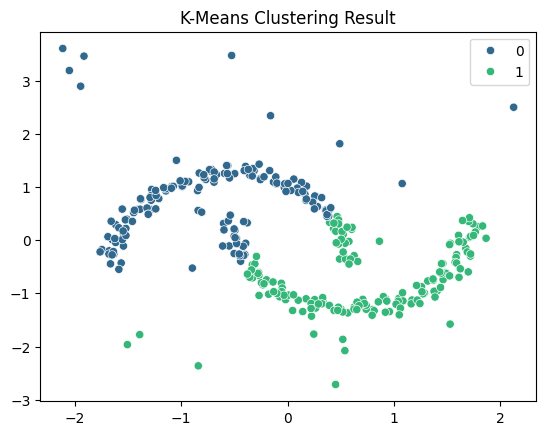

In [ ]:
# YOUR CODE HERE
# 1. Initialize KMeans with k=2
kmeans = KMeans(n_clusters = 2, init = 'k-means++', max_iter = 400, random_state = 42)

# 2. Fit and Predict
y_means = kmeans.fit_predict(X)

# 3. Plot the results using colors for clusters

kmeans = KMeans(n_clusters=2, random_state=42)
y_kmeans = kmeans.fit_predict(X)

# plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, cmap='viridis')
# plt.title("K-Means Clustering Result")
# plt.show()

sns.scatterplot(x = X[:, 0], y = X[:, 1], hue = y_kmeans, palette = 'viridis')
plt.title("K-Means Clustering Result")
plt.show()

## Task 2: Parameter Selection (The Elbow Method)
DBSCAN requires an `eps` value. A common technique is to plot the distance to the **k-th nearest neighbor** (usually k = MinPts - 1). We look for the 'elbow' where the distance increases sharply.

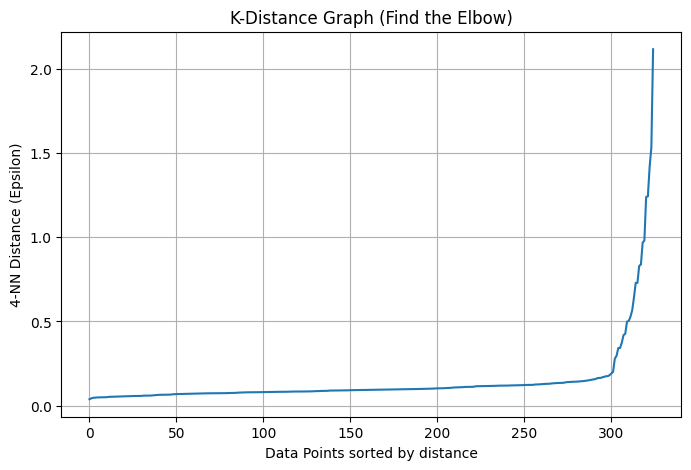

In [ ]:
# Calculate 4-th nearest neighbors
neighbors = NearestNeighbors(n_neighbors=4)
neighbors_fit = neighbors.fit(X)
distances, indices = neighbors_fit.kneighbors(X)

# Sort distances and plot
distances = np.sort(distances[:, 3], axis=0)

plt.figure(figsize=(8,5))
plt.plot(distances)
plt.title("K-Distance Graph (Find the Elbow)")
plt.xlabel("Data Points sorted by distance")
plt.ylabel("4-NN Distance (Epsilon)")
plt.grid(True)
plt.show()

## Task 3: Apply DBSCAN
Based on the graph above, pick an epsilon (likely between 0.2 and 0.3) and apply DBSCAN with `min_samples=4`.

In [12]:
# YOUR CODE HERE
eps_choice = 0.3
dbscan = DBSCAN(eps=eps_choice, min_samples=4)
labels = dbscan.fit_predict(X)

# Example setup:
# dbscan = DBSCAN(eps=0.25, min_samples=4)
# labels = dbscan.fit_predict(X)

print(f"Unique clusters found: {set(labels)}")

Unique clusters found: {np.int64(0), np.int64(1), np.int64(-1)}


## Task 4: Anomaly Analysis
Visualize the final clusters. Pay special attention to the points labeled `-1`. These are the anomalies detected by DBSCAN.

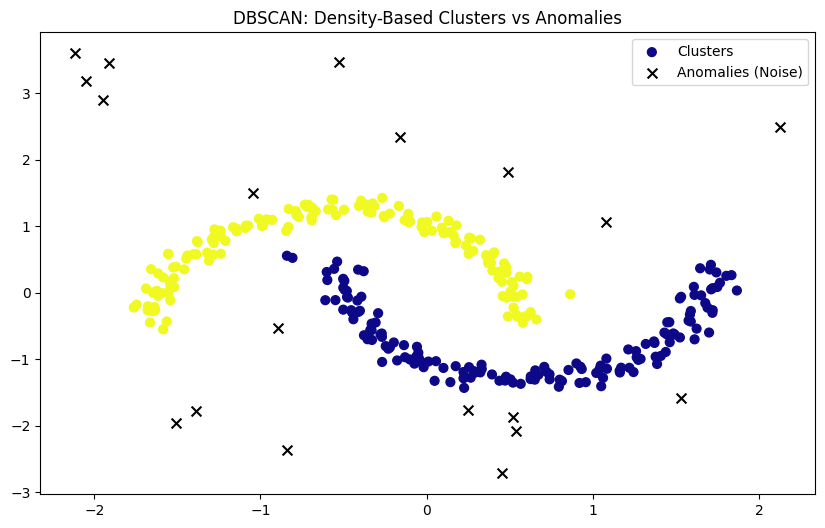

In [13]:
# Separate noise from clusters
core_mask = labels != -1

plt.figure(figsize=(10,6))
# Plot valid clusters
plt.scatter(X[core_mask, 0], X[core_mask, 1], c=labels[core_mask], cmap='plasma', s=40, label='Clusters')
# Plot noise in Black
plt.scatter(X[~core_mask, 0], X[~core_mask, 1], c='black', marker='x', s=50, label='Anomalies (Noise)')

plt.title("DBSCAN: Density-Based Clusters vs Anomalies")
plt.legend()
plt.show()

## Conclusion & Reflection
Look at your final plot.
1. How did DBSCAN perform on the 'moon' shapes compared to K-Means?
2. Why is identifying the black 'X' marks important for an e-commerce platform in the context of fraud detection?
3. What happens if you significantly increase the Epsilon value?

### 1. How did DBSCAN perform on the 'moon' shapes compared to K-Means?
Ans: The DBSCAN performed better than kmeans because it seperated the clusters based on density rather than the distances. It provides more meaningful clustering while ignoring the noises that might have impacted the outcome.

### 2. Why is identifying the black 'X' marks important for an e-commerce platform in the context of fraud detection?

Ans: The X marks refers to the anomalies which indicates the frauds or scams that might happen to the e-commerce platforms. Identifying the X marks helps to reduce the anomalies while maintaining the proper clusters without any involvement of anomalies.

### 3. What happens if you significantly increase the Epsilon value?

Ans: If I significantly increase the epsilon value then it will create a single big cluster which might involve noises or anomalies. Also it might take other values which should be in different clusters which might give inaccurate predictions.